##0. Loading Datasets

In [252]:
from google.colab import drive
drive.flush_and_unmount()

In [253]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [254]:
import os
base_path = "/content/drive/MyDrive/Project_1_group_3_main/"
print(os.listdir(base_path))

['WHR_2023.csv', 'newcountryvars.csv', 'QMSSGR5074_Project_1.ipynb', 'fitted_preprocess.joblib', 'Project_1_Group_3.ipynb']


In [255]:
#Loading Dataset
import pandas as pd

whr_df = pd.read_csv(base_path + "WHR_2023.csv")
countrydata = pd.read_csv(base_path + "newcountryvars.csv")

print("WHR shape:", whr_df.shape)
print("Country data shape:", countrydata.shape)

whr_df.head()


WHR shape: (137, 9)
Country data shape: (174, 8)


,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,Finland,Western Europe,7.804,1.888,1.585,0.535,0.772,0.126,0.535
1,Denmark,Western Europe,7.586,1.949,1.548,0.537,0.734,0.208,0.525
2,Iceland,Western Europe,7.530,1.926,1.620,0.559,0.738,0.250,0.187
3,Israel,Middle East and North Africa,7.473,1.833,1.521,0.577,0.569,0.124,0.158
4,Netherlands,Western Europe,7.403,1.942,1.488,0.545,0.672,0.251,0.394


In [256]:
import numpy as np
from sklearn.model_selection import train_test_split

print("WHR columns:", whr_df.columns.tolist())
print("Countrydata columns:", countrydata.columns.tolist())

whr_df['happiness_category'] = pd.qcut(whr_df['happiness_score'],
                      q=5,
                      labels=['Very Low', 'Low','Average', 'High', 'Very High']
                     )

# Select features and target
X = whr_df.drop(columns=['happiness_score', 'happiness_category'])
y = whr_df['happiness_category']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Convert y_train and y_test to numerical labels
y_train_cat = y_train.astype("category")
y_test_cat = y_test.astype("category").cat.set_categories(y_train_cat.cat.categories)

y_train_labels = y_train_cat.cat.codes
y_test_labels = y_test_cat.cat.codes

label_mapping = dict(enumerate(y_train_cat.cat.categories))
print("Label mapping:", label_mapping)



WHR columns: ['country', 'region', 'happiness_score', 'gdp_per_capita', 'social_support', 'healthy_life_expectancy', 'freedom_to_make_life_choices', 'generosity', 'perceptions_of_corruption']
Countrydata columns: ['country_name', 'population', 'population_below_poverty_line', 'hdi', 'life_expectancy', 'expected_years_of_schooling', 'mean_years_of_schooling', 'gni']
Label mapping: {0: 'Very Low', 1: 'Low', 2: 'Average', 3: 'High', 4: 'Very High'}


**Conceptual Question**

1. What does y_train.astype('category').cat.codes do?

This operation converts the target variable from string labels (e.g., "Very Low", "High") into categorical format and then assigns each category a unique integer code (e.g., 0–4). These numeric codes allow machine learning models to process the target variable, since most algorithms require numerical input rather than text labels.

2. What is the difference between y_train_labels and y_train?

y_train contains the original categorical labels, while y_train_labels contains the corresponding numeric encodings of those categories.
The encoded version is used for model training, whereas the original labels are useful for interpretation and reporting results.

###Merge two datasets

In [257]:
# Merge in new data to X_train and X_test by taking "country" from first table and "country_name" from 2nd table.
# Also check which countries are common in both the datasets, and which type of merge will you perform for the best results.
# Hint: Look on the 'how' parameter of merge function of pandas.

train_countries = set(X_train["country"])
aux_countries = set(countrydata["country_name"])

common = train_countries.intersection(aux_countries)
missing = train_countries - aux_countries

print("Countries in X_train:", len(train_countries))
print("Countries in countrydata:", len(aux_countries))
print("Common:", len(common))
print("Missing in countrydata (sample):", list(missing)[:10])

X_train = (
    X_train.merge(countrydata, how="left", left_on="country", right_on="country_name")
          .drop(columns=["country_name"])
)

X_test = (
    X_test.merge(countrydata, how="left", left_on="country", right_on="country_name")
         .drop(columns=["country_name"])
)

print("After merge:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)
display(X_train.head(2))

Countries in X_train: 95
Countries in countrydata: 174
Common: 89
Missing in countrydata (sample): ['North Macedonia', 'Turkiye', 'Vietnam', 'Taiwan Province of China', 'Czechia', 'Hong Kong S.A.R. of China']
After merge:
X_train: (95, 15) X_test: (42, 15)


,country,region,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,population,population_below_poverty_line,hdi,life_expectancy,expected_years_of_schooling,mean_years_of_schooling,gni
0,Madagascar,Sub-Saharan Africa,0.632,0.779,0.178,0.187,0.177,0.134,25570895.0,70.7,0.512149,65.515,10.34614,6.145955,1319.699397
1,Mauritania,Sub-Saharan Africa,1.099,0.764,0.244,0.320,0.130,0.195,4420184.0,31.0,0.513106,63.239,8.46379,4.266000,3527.264154


## 1. Exploratory Data Analysis and Visualization (EDAV)

In [258]:
print(X_train.dtypes)

country                           object
region                            object
gdp_per_capita                   float64
social_support                   float64
healthy_life_expectancy          float64
freedom_to_make_life_choices     float64
generosity                       float64
perceptions_of_corruption        float64
population                       float64
population_below_poverty_line    float64
hdi                              float64
life_expectancy                  float64
expected_years_of_schooling      float64
mean_years_of_schooling          float64
gni                              float64
dtype: object


### Describe What You Observe

There are 2 categorical features and 13 numerical features in total

In [259]:
###Part1 todo
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))
print("\nDtype counts:")
display(X_train.dtypes.value_counts())

Numeric columns: 13
Categorical columns: 2

Dtype counts:


,count
float64,13
object,2


### Missing Values Analysis

Compute the number and percentage of missing values for each column and present the results in a clear summary table.

In [260]:
missing_count = X_train.isna().sum()
missing_pct = (missing_count / len(X_train)).round(4)

missing_table = (
    pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct})
    .sort_values("missing_count", ascending=False)
)

display(missing_table[missing_table["missing_count"] > 0])

,missing_count,missing_pct
population_below_poverty_line,16,0.1684
mean_years_of_schooling,7,0.0737
expected_years_of_schooling,7,0.0737
life_expectancy,7,0.0737
gni,7,0.0737
population,6,0.0632
hdi,6,0.0632


### Distribution of Key Numerical Features

Select relevant numerical features and plot their histograms. Choose features that may influence the target variable, and briefly comment on notable patterns, skewness, or outliers.






By looking at the distribution of notable features which might impact our dependent variable, such as GDP per capita, social support, and freedom to make life choices, we observe that these variables are highly left-skewed. This indicates that most countries cluster at relatively high values, while a small number of countries have substantially lower scores. Such skewness may affect model performance and violate assumptions of certain parametric models. Therefore, transformation techniques or normalization may be considered to improve model stability.

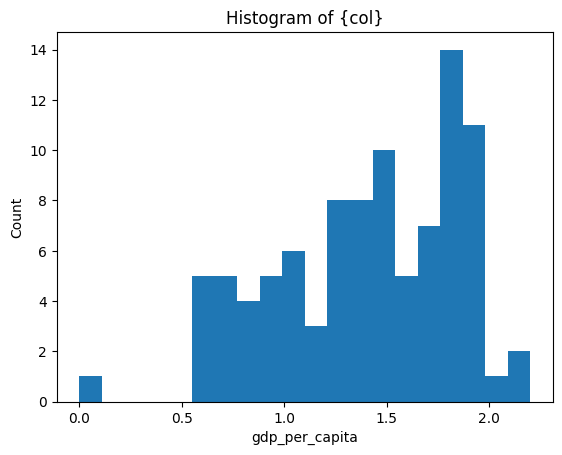

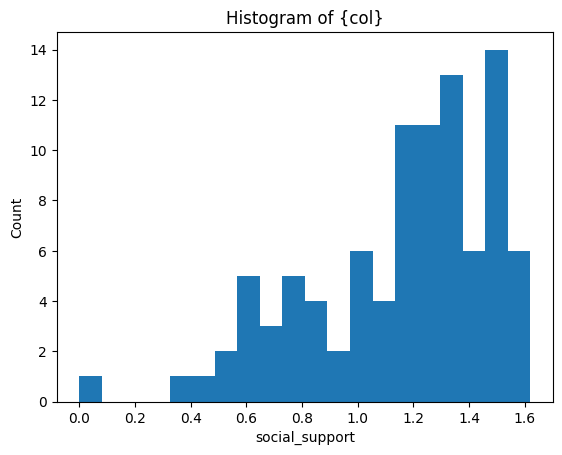

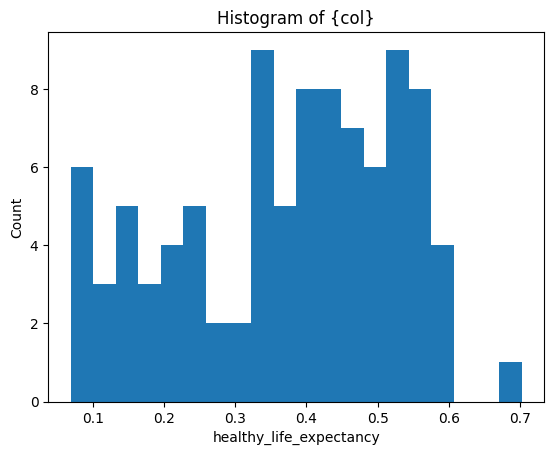

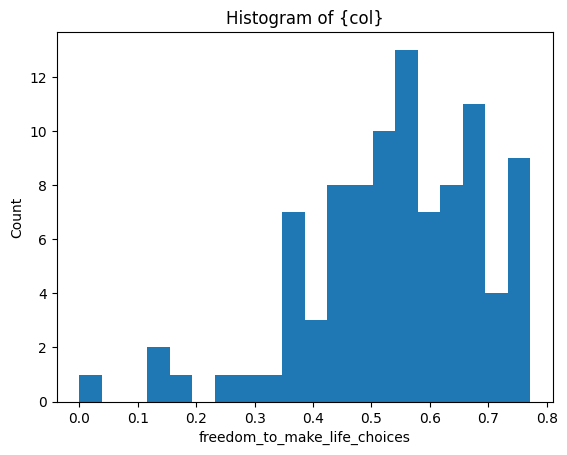

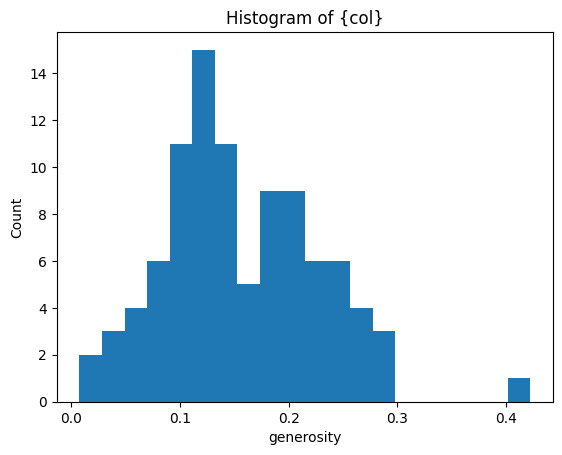

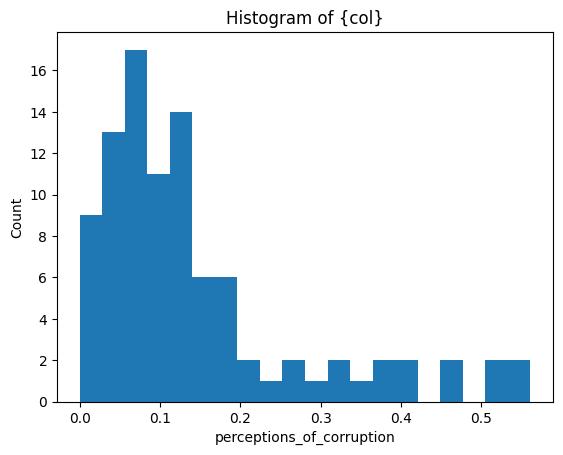

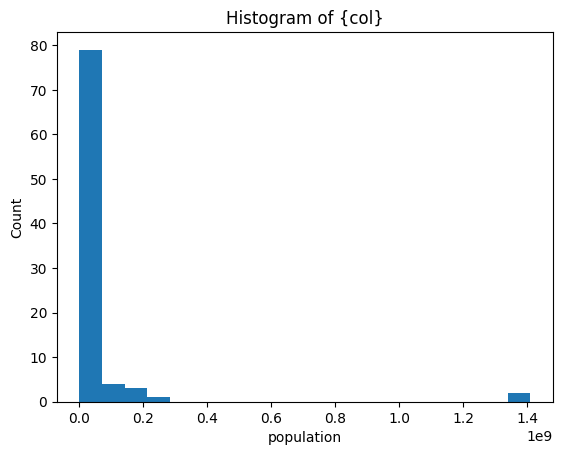

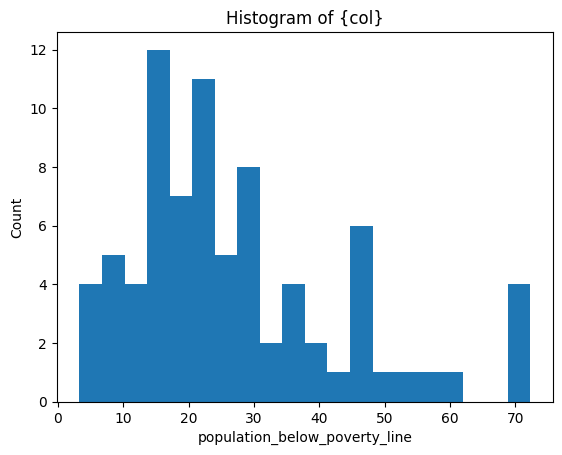

In [261]:
import matplotlib.pyplot as plt

plot_num = num_cols[:8]
for col in plot_num:
    plt.figure()
    plt.hist(X_train[col].dropna(), bins=20)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title("Histogram of {col}")
    plt.show()

### Distribution of Categorical Variables

Plot the distribution of relevant categorical variables using appropriate visualizations (e.g., count plots or bar charts). Briefly comment on class imbalance or notable patterns.

We observed some feature imbalance in the country variable categorized by region, with African countries dominating the dataset. This uneven distribution suggests that the dataset over-represents certain regions while under-representing others. Such imbalance may introduce regional bias into the model, potentially affecting generalization performance when applied to more globally balanced population in certain models that greatly relies on Euclidian distance.

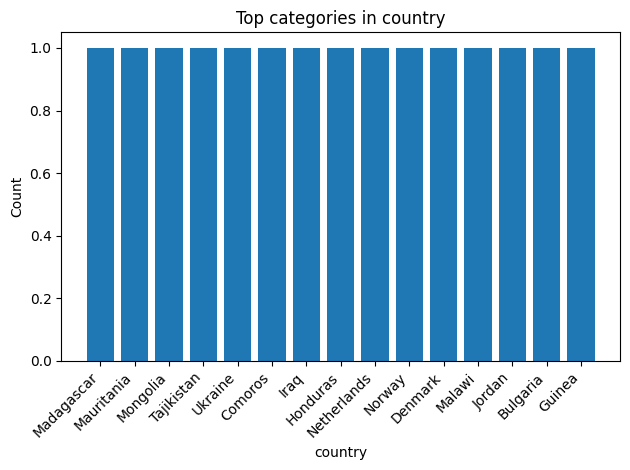

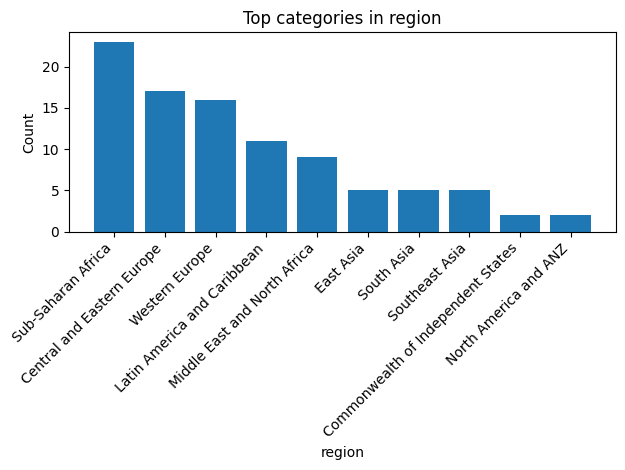

In [262]:
plot_cat = cat_cols[:5]
for col in plot_cat:
    vc = X_train[col].astype(str).value_counts(dropna=False).head(15)
    plt.figure()
    plt.bar(vc.index.astype(str), vc.values)
    plt.xticks(rotation=45, ha="right")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Top categories in {col}")
    plt.tight_layout()
    plt.show()

### Feature Correlation Analysis

Analyze the relationships between numerical features using correlation coefficients. Compute and visualize:

- **Pearson correlation** — linear relationships
- **Spearman correlation** — monotonic relationships
- **Kendall correlation** — rank-based relationships

Use correlation matrices and heatmaps where appropriate. Briefly interpret strong positive or negative correlations and discuss potential multicollinearity.

Per capita GDP is positively correlated with HDI, life expectancy, years of schooling, and GNI, and negatively correlated with the population below the poverty line. This suggests that economic development tends to coincide with improvements in human capital, health outcomes, and overall living standards. Wealthier countries not only generate higher income but also invest more in education and healthcare systems, which reinforces long-term development.

From a policy perspective, this indicates that GDP growth may have spillover effects on social welfare indicators. However, since GDP per capita is also highly correlated with social support (r ≥ 0.8), there is potential multicollinearity in the model. This suggests that these variables may capture overlapping aspects of development, such as institutional strength or social infrastructure. Therefore, when interpreting regression coefficients, we should be cautious in attributing effects to any single economic variable, as they may reflect broader structural development factors rather than isolated impacts.

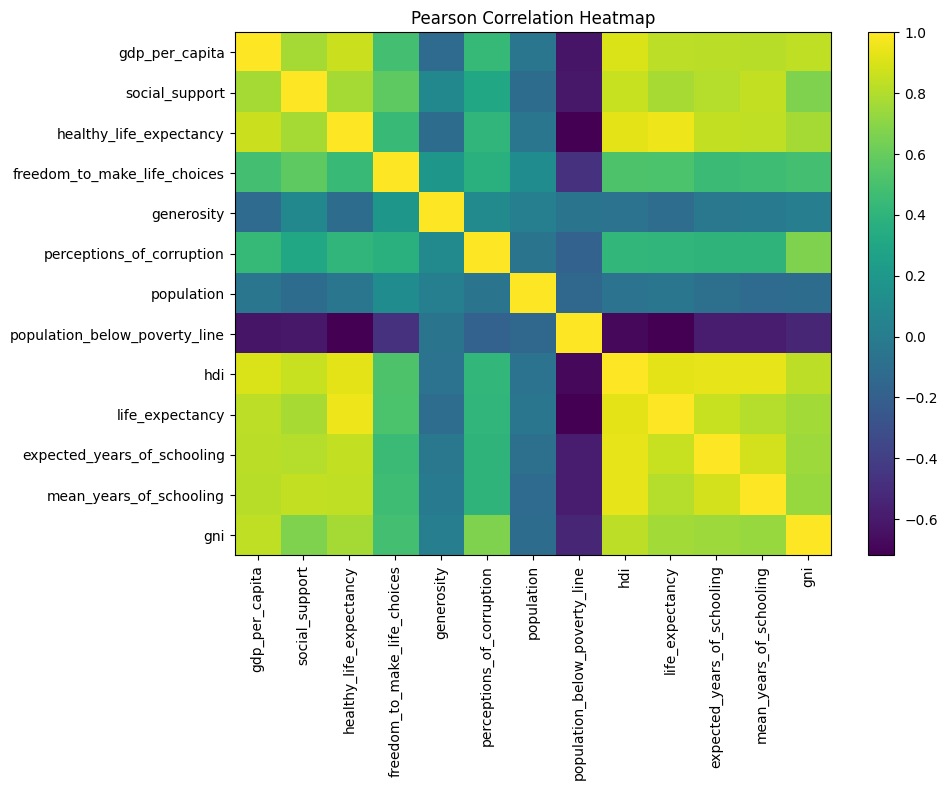

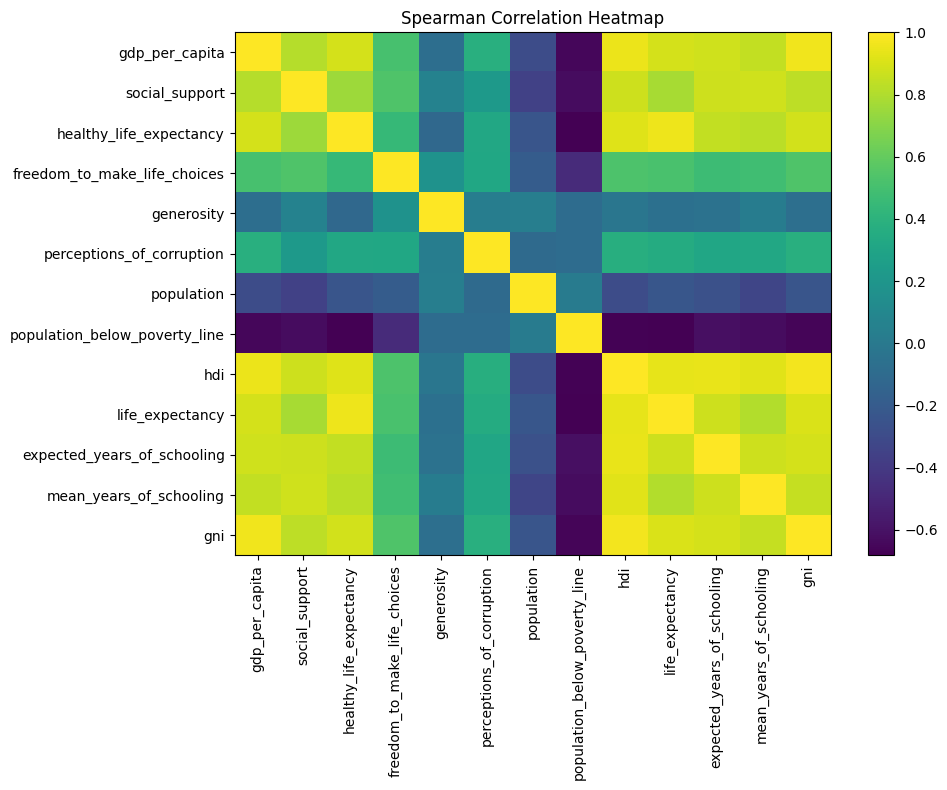

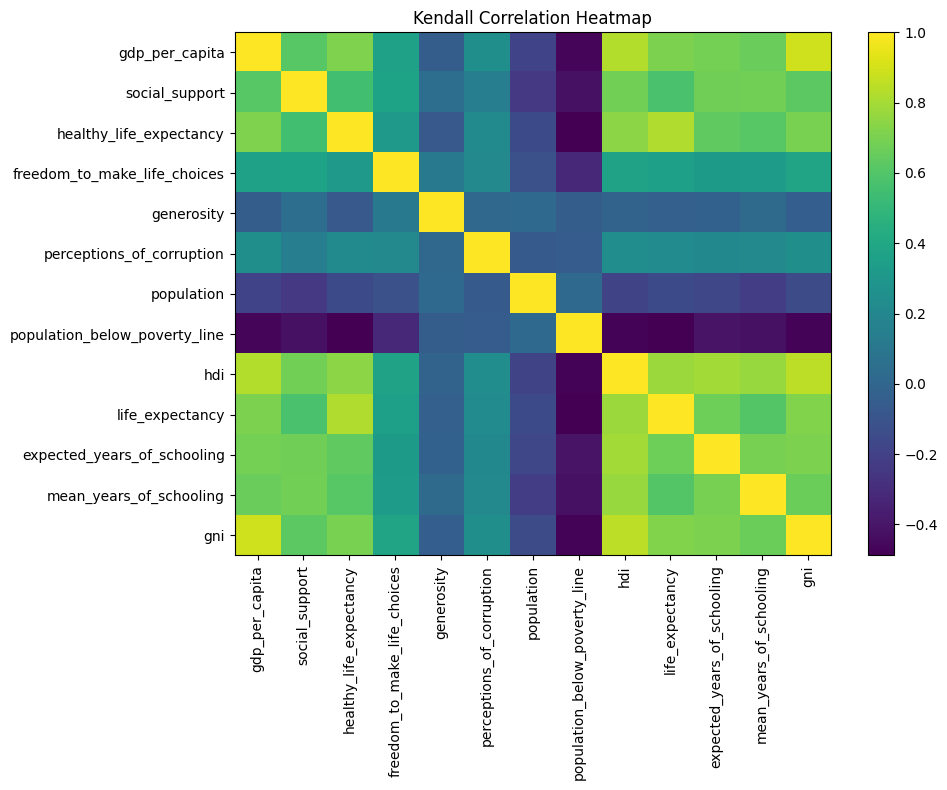

Top 10 absolute Pearson correlations:


,,0
healthy_life_expectancy,life_expectancy,0.959434
life_expectancy,healthy_life_expectancy,0.959434
hdi,expected_years_of_schooling,0.939177
expected_years_of_schooling,hdi,0.939177
hdi,mean_years_of_schooling,0.934324
mean_years_of_schooling,hdi,0.934324
hdi,life_expectancy,0.932439
life_expectancy,hdi,0.932439
healthy_life_expectancy,hdi,0.929456
hdi,healthy_life_expectancy,0.929456


In [263]:
import numpy as np

num_df = X_train[num_cols].copy()

for method in ["pearson", "spearman", "kendall"]:
    corr = num_df.corr(method=method)

    plt.figure(figsize=(10, 8))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title(f"{method.title()} Correlation Heatmap")
    plt.tight_layout()
    plt.show()

# Top correlations (Pearson)
corr_abs = num_df.corr().abs()
np.fill_diagonal(corr_abs.values, 0)
top_pairs = corr_abs.unstack().sort_values(ascending=False).head(10)
print("Top 10 absolute Pearson correlations:")
display(top_pairs)

### Bivariate Analysis and Relationship Exploration

Explore relationships between features and examine how they associate with the target variable. Include:

- Bivariate plots (e.g., scatter plots, box plots, grouped bar charts)
- Correlation tables
- Comparisons of feature distributions across target classes

Briefly summarize key relationships and any patterns that may influence model performance.

According to the boxplot, higher happiness scores are generally associated with higher levels of GDP per capita, suggesting a positive relationship between economic prosperity and well-being. The variance appears to be larger in the lower GDP categories, indicating greater heterogeneity among lower-income countries. As GDP increases, the distribution becomes relatively more concentrated, suggesting more stable happiness outcomes in higher-income groups.

Additionally, several outliers are present across categories. These extreme observations may influence model estimation in linear regression, as the method is sensitive to outliers due to its reliance on squared errors. As a result, outliers could disproportionately affect coefficient estimates and potentially reduce model stability and predictive performance.

/tmp/ipykernel_285/2423592458.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_class, labels=classes)


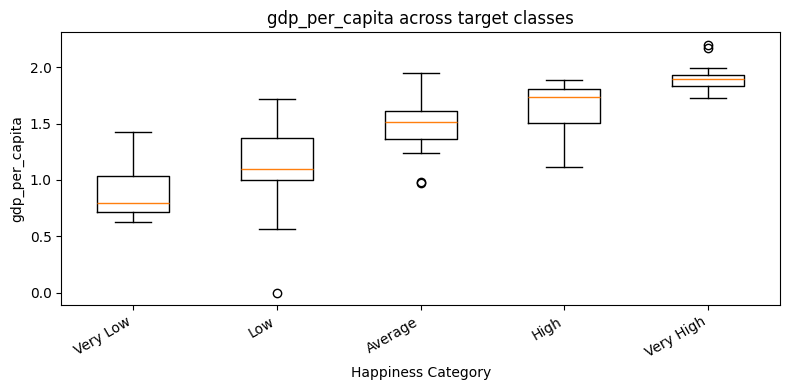

/tmp/ipykernel_285/2423592458.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_class, labels=classes)


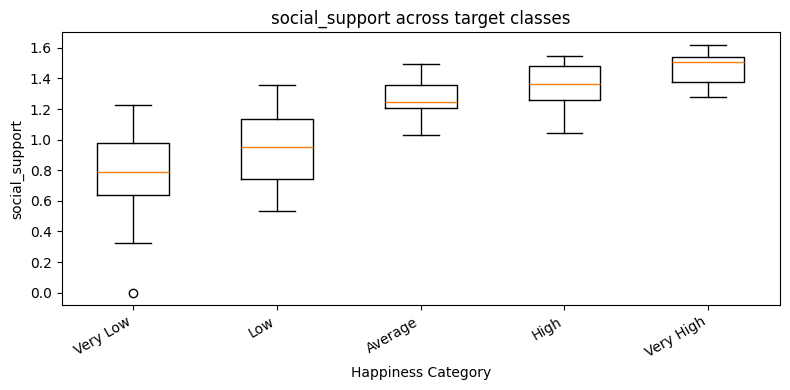

In [264]:
eda_df = X_train.copy()
eda_df["happiness_category"] = y_train.reset_index(drop=True)

two_cols = num_cols[:2]
classes = list(label_mapping.values())

for col in two_cols:
    plt.figure(figsize=(8,4))
    data_by_class = [eda_df.loc[eda_df["happiness_category"] == c, col].dropna() for c in classes]
    plt.boxplot(data_by_class, labels=classes)
    plt.xticks(rotation=30, ha="right")
    plt.xlabel("Happiness Category")
    plt.ylabel(col)
    plt.title(f"{col} across target classes")
    plt.tight_layout()
    plt.show()

### Outlier Detection

Identify potential outliers in the numerical features using appropriate methods such as:

- Box plots
- Z-score analysis
- Interquartile Range (IQR) method

Highlight any significant anomalies and briefly comment on whether they should be retained, transformed, or removed.

Outliers were examined using box plots, Z-score analysis (|z| > 3), and the Interquartile Range (IQR) method (1.5 × IQR rule).

The box plots indicate the presence of several extreme values across numerical variables, particularly in indicators such as corruption score. The IQR and Z-score methods confirm that a small proportion of observations fall outside conventional thresholds.

These anomalies may represent genuinely high-performing or low-performing countries rather than data errors. Since linear regression is sensitive to extreme values due to its squared-error objective function, such outliers may disproportionately influence coefficient estimates.

Given that the dataset reflects real-world country-level variation, these observations are likely meaningful rather than erroneous. Therefore, instead of removing them outright, a log transformation (e.g., log(GDP per capita)) or robust regression techniques may be more appropriate to reduce skewness while preserving information.

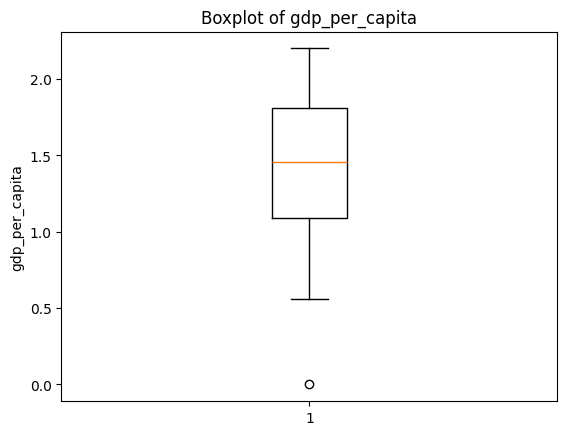

IQR outliers in gdp_per_capita: 1
Z-score (>3) outliers in gdp_per_capita: 1
----------------------------------------


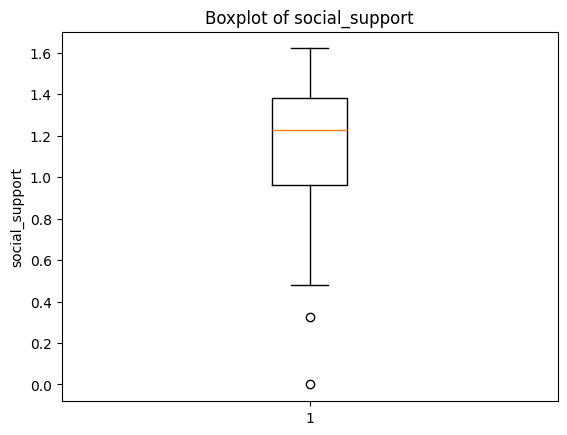

IQR outliers in social_support: 2
Z-score (>3) outliers in social_support: 1
----------------------------------------


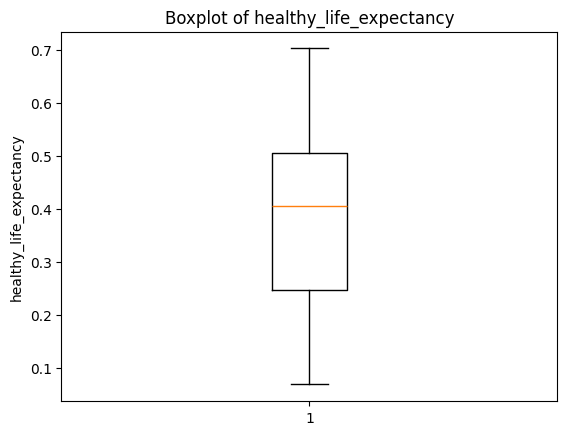

IQR outliers in healthy_life_expectancy: 0
Z-score (>3) outliers in healthy_life_expectancy: 0
----------------------------------------


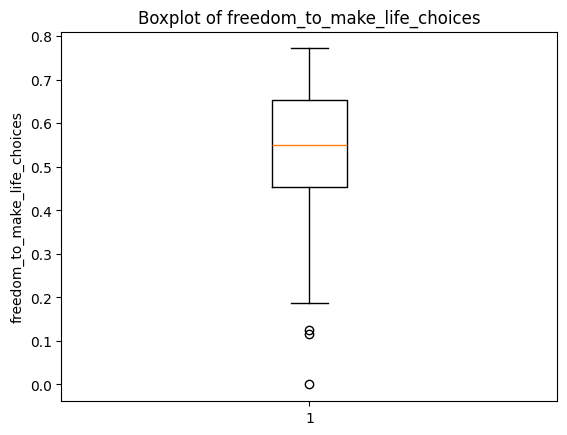

IQR outliers in freedom_to_make_life_choices: 3
Z-score (>3) outliers in freedom_to_make_life_choices: 1
----------------------------------------


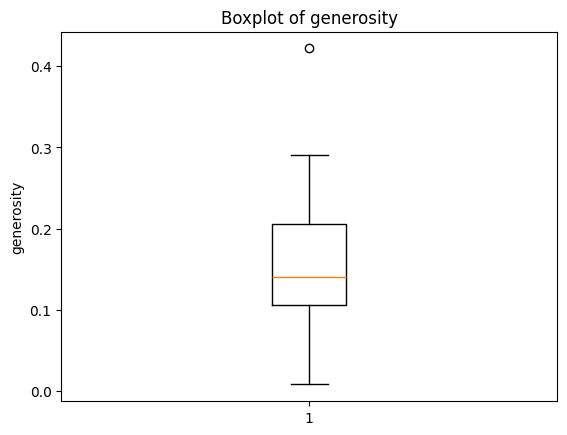

IQR outliers in generosity: 1
Z-score (>3) outliers in generosity: 1
----------------------------------------


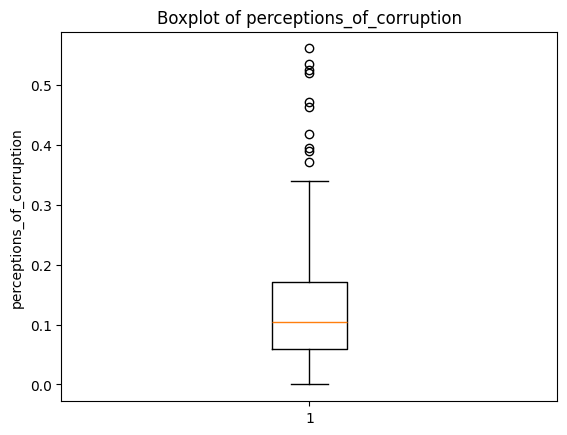

IQR outliers in perceptions_of_corruption: 10
Z-score (>3) outliers in perceptions_of_corruption: 1
----------------------------------------


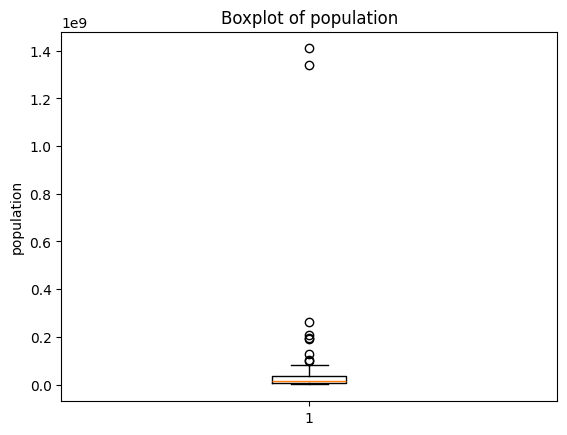

IQR outliers in population: 9
Z-score (>3) outliers in population: 2
----------------------------------------


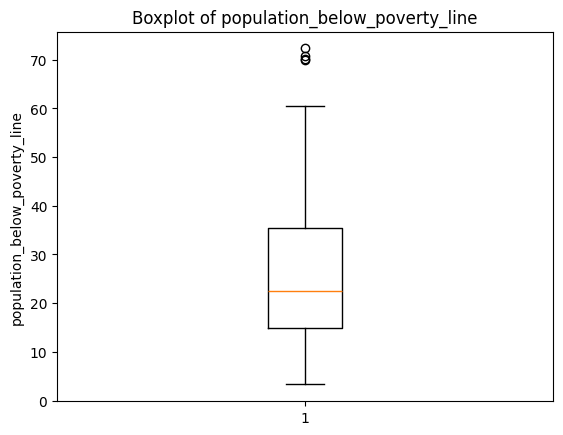

IQR outliers in population_below_poverty_line: 4
Z-score (>3) outliers in population_below_poverty_line: 0
----------------------------------------


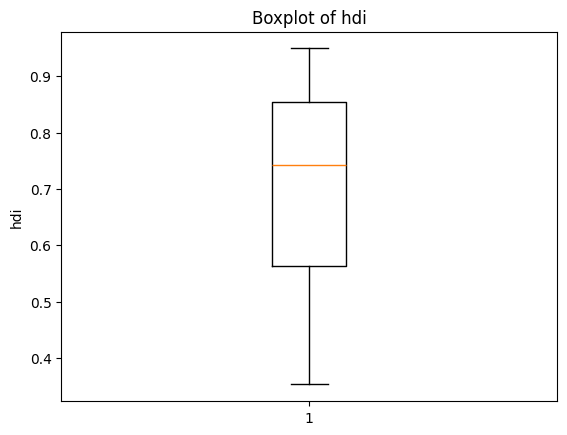

IQR outliers in hdi: 0
Z-score (>3) outliers in hdi: 0
----------------------------------------


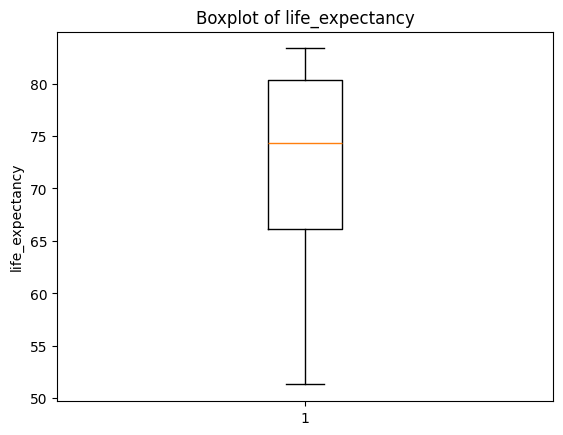

IQR outliers in life_expectancy: 0
Z-score (>3) outliers in life_expectancy: 0
----------------------------------------


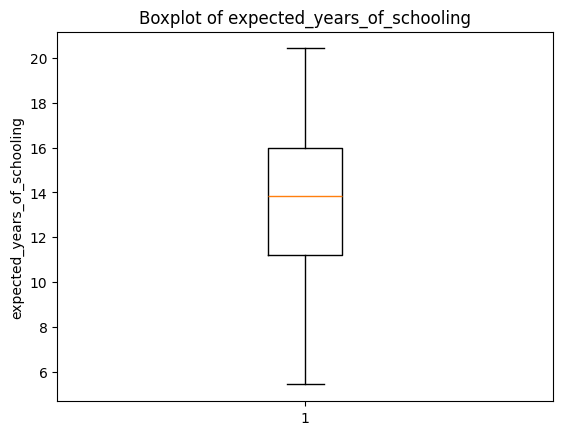

IQR outliers in expected_years_of_schooling: 0
Z-score (>3) outliers in expected_years_of_schooling: 0
----------------------------------------


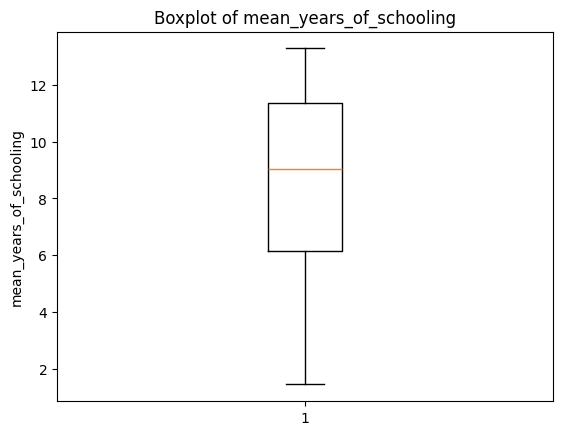

IQR outliers in mean_years_of_schooling: 0
Z-score (>3) outliers in mean_years_of_schooling: 0
----------------------------------------


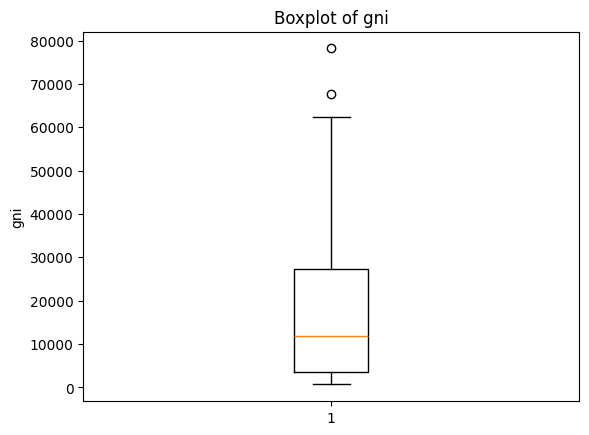

IQR outliers in gni: 2
Z-score (>3) outliers in gni: 1
----------------------------------------


In [265]:
from scipy.stats import zscore

for col in num_cols:

    s = X_train[col].dropna()

    plt.figure()
    plt.boxplot(s)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    iqr_outliers = s[(s < lower) | (s > upper)]
    print(f"IQR outliers in {col}: {len(iqr_outliers)}")

    zs = zscore(s)
    z_outliers = s[np.abs(zs) > 3]
    print(f"Z-score (>3) outliers in {col}: {len(z_outliers)}")

    print("-" * 40)

### Observations and General Comments

Summarize your key findings from the exploratory analysis. Include:

- Important patterns or relationships identified
- Presence of missing values or outliers
- Potential feature engineering considerations
- Any preprocessing steps that should be applied before modeling

Keep your comments concise and evidence-based.

The exploratory analysis reveals several important patterns. GDP per capita is positively correlated with HDI, life expectancy, years of schooling, and GNI, and negatively correlated with the population below the poverty line. This suggests that economic development is closely associated with broader improvements in human capital and social well-being. Additionally, happiness scores increase with GDP per capita, indicating a positive relationship between economic prosperity and life satisfaction.

Strong correlations (e.g., r ≥ 0.8 between GDP per capita and social support) suggest potential multicollinearity, implying that some variables may capture overlapping aspects of structural development. This may affect coefficient interpretability in linear regression models.

Outlier detection using box plots, IQR, and Z-score methods identified several extreme values, particularly in economic indicators. These outliers likely reflect genuine cross-country disparities rather than data errors, but they may influence regression estimates due to the squared-error objective.

Before modeling, it would be appropriate to address skewness (e.g., log transformation for GDP-related variables), assess multicollinearity using VIF, and standardize numerical features if regularized models are applied. These preprocessing steps can improve model stability and interpretability.

---

## 2. Feature Engineering

Apply log transformations to normalize skewed numerical features and improve model stability (if applicable).

In [266]:
###PART2
import numpy as np

# log1p for skewed numeric features (safe for zeros)
skewness = X_train[num_cols].skew(numeric_only=True)
skewed_cols = skewness[skewness.abs() > 1].index.tolist()
print("Skewed cols (|skew|>1):", skewed_cols)

for col in skewed_cols:
    if (X_train[col].dropna() >= 0).all() and (X_test[col].dropna() >= 0).all():
        X_train[col] = np.log1p(X_train[col])
        X_test[col] = np.log1p(X_test[col])



Skewed cols (|skew|>1): ['perceptions_of_corruption', 'population', 'population_below_poverty_line', 'gni']


Create at least one interaction feature to capture relationships between existing variables and enhance predictive power.

In [267]:
# one interaction feature
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()  # refresh
if len(num_cols) >= 2:
    a, b = num_cols[0], num_cols[1]
    inter_name = f"{a}_x_{b}"
    X_train[inter_name] = X_train[a] * X_train[b]
    X_test[inter_name] = X_test[a] * X_test[b]
    print("Created interaction feature:", inter_name)

Created interaction feature: gdp_per_capita_x_social_support


---

## 3. Data Preprocessing

Use `sklearn`'s `ColumnTransformer` to preprocess the data. Write a preprocessing function and save the fitted preprocessor for later use.

In [268]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import joblib

drop_cols = [c for c in ["country", "region"] if c in X_train.columns]

num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols and c not in drop_cols]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

preprocess.fit(X_train.drop(columns=drop_cols, errors="ignore"))
joblib.dump(preprocess, base_path + "fitted_preprocess.joblib")
print("Saved fitted preprocessor.")

def preprocessor(data):
    data_clean = data.drop(columns=drop_cols, errors="ignore")
    return preprocess.transform(data_clean)

print("Processed shape (train):", preprocessor(X_train).shape)
print("Processed shape (test):", preprocessor(X_test).shape)

Saved fitted preprocessor.
Processed shape (train): (95, 14)
Processed shape (test): (42, 14)


### Explanation

Briefly explain what the preprocessing steps above do and why they are needed.

If you changed the imputation strategy (or any other preprocessing choice), please state:

- What you changed
- Why you made that change

Numerical features are imputed using the median and standardized to improve model stability and ensure comparability across variables. Categorical features are imputed using the most frequent value and one-hot encoding(get dummies) to convert them into a machine-readable format. The preprocessing steps help handle missing data, avoid scale-related bias, and ensure consistency between training and testing data.

### Conceptual Question

Explain the differences between the following:

- The `preprocessor` **object**
- The `preprocess` **object**
- The `preprocessor` **function**
- The final `preprocessed_data` **returned**

Clearly distinguish between objects, functions, and transformed data.

`preprocess` is a fitted columnTransformer object that defines and applies all preprocessing steps to numerical and categorical features. After calling .fit(), it has learned parameters such as medians, scaling statistics, and category mappings from the training data.

numeric_pipe and categorical_pipe are Pipeline objects that specify the preprocessing steps for numerical and categorical variables. They define the sequence of transformations but only learn parameters during preprocess.fit().

The `preprocessor` function is a user-defined function that first drops unnecessary columns and then calls preprocess.transform(). It does not learn any parameters; it simply applies the already fitted transformer to new data.

the final data returned is the output of the preprocessor function, ready for model training

## 4. Model Training and Saving Artifacts

Fit the model on the preprocessed training data. Save the fitted preprocessor and the trained model for reuse (e.g., inference and submission).

In [269]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1)
model.fit(preprocessor(X_train), y_train_labels)

joblib.dump(preprocessor, "preprocessor.joblib")
joblib.dump(model, "rf_model.joblib")

model.score(preprocessor(X_test), y_test_labels)

0.4523809523809524

## 5. Model Evaluation

Generate predictions using `X_test`. Compare the predictions with the true labels in `y_test` using appropriate evaluation metrics.

In [270]:
prediction_labels = model.predict(preprocessor(X_test))

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Accuracy Score
print("Accuracy:", accuracy_score(y_test_labels, prediction_labels))

#Classification Report
print("\nClassification Report:")
print(classification_report(y_test_labels, prediction_labels))

#Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_labels, prediction_labels))

Accuracy: 0.4523809523809524

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.22      0.27         9
           1       0.18      0.25      0.21         8
           2       0.42      0.62      0.50         8
           3       0.67      0.50      0.57         8
           4       0.86      0.67      0.75         9

    accuracy                           0.45        42
   macro avg       0.49      0.45      0.46        42
weighted avg       0.50      0.45      0.46        42


Confusion Matrix:
[[2 7 0 0 0]
 [4 2 2 0 0]
 [0 2 5 1 0]
 [0 0 3 4 1]
 [0 0 2 1 6]]


## 6. Hyperparameter Experimentation

Repeat the training and evaluation process with different model parameters to improve performance. Track results across experiments and report the best-performing configuration.

In [271]:
model_2 = RandomForestClassifier(
    n_estimators=600,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1)

model_2.fit(preprocessor(X_train), y_train_labels)

prediction_labels_2 = model_2.predict(preprocessor(X_test))
score_2 = accuracy_score(y_test_labels, prediction_labels_2)
score_2

0.5238095238095238

### Reflection on Hyperparameter Changes

Briefly explain:

- What parameters you changed
- What each parameter controls
- Why the changes improved (or did not improve) performance

Support your explanation with evidence from your results.

I modified three hyperparameters of the Random Forest model:

**n_estimators:** increased from 300 to 600

**max_depth:** set to 15 instead of unlimited depth

**min_samples_leaf:** increased from 1 to 2.

**n_estimators** controls the number of decision trees in the forest. Increasing the number of trees generally improves model stability and reduces variance by averaging across more trees.

**max_depth** limits how deep each tree can grow. Constraining depth helps prevent overfitting by reducing model complexity and limiting how finely the model can split the data.

**min_samples_leaf** controls the minimum number of samples required in a leaf node. Increasing this value prevents the model from creating very small leaves that may capture noise rather than meaningful patterns.

These changes improved the test accuracy from 0.452 to 0.524, which is a 7% percentage of points increase. It suggested that the first model was a little bit overfitting, while the second one improved generalization performance.

In [272]:
#Evaluate Model 2:

#-- Generate predicted y values (Model 2)
prediction_labels = model_2.predict(preprocessor(X_test))

# Accuracy
print("Accuracy:", accuracy_score(y_test_labels, prediction_labels))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_labels, prediction_labels))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_labels, prediction_labels))

Accuracy: 0.5238095238095238

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.22      0.29         9
           1       0.27      0.38      0.32         8
           2       0.50      0.75      0.60         8
           3       0.71      0.62      0.67         8
           4       0.86      0.67      0.75         9

    accuracy                           0.52        42
   macro avg       0.55      0.53      0.52        42
weighted avg       0.55      0.52      0.52        42


Confusion Matrix:
[[2 7 0 0 0]
 [3 3 2 0 0]
 [0 1 6 1 0]
 [0 0 2 5 1]
 [0 0 2 1 6]]


**Discussion Question**

Do you think it is worth making more changes to the parameters? Should we keep trying random values and see what works better? What is an alternative to doing this manually?

It is worth further tuning, but instead of manually trying random values, a more reliable approach is to use cross-validated hyperparameter search (e.g., GridSearchCV or RandomizedSearchCV) to efficiently and reproducibly identify the best configuration without overfitting to the test set.

In [273]:
# Submit a third model using GridSearchCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid = {
 "n_estimators": [300, 600],
  "max_depth": [None, 12, 16],
  "min_samples_leaf": [1, 2],
  "max_features": ["sqrt"]
}

gridmodel = GridSearchCV(rf, param_grid, cv=5, scoring="accuracy", n_jobs=-1)

gridmodel.fit(preprocessor(X_train), y_train_labels)

print("best mean cross-validation score: {:.3f}".format(gridmodel.best_score_))
print("best parameters: {}".format(gridmodel.best_params_))

best_model = gridmodel.best_estimator_
prediction_labels_3 = best_model.predict(preprocessor(X_test))

best mean cross-validation score: 0.568
best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 600}


In [274]:
#Submit Model 3:

#-- Generate predicted values
prediction_labels = gridmodel.best_estimator_.predict(preprocessor(X_test))

#Accuracy:
print("Accuracy:", accuracy_score(y_test_labels, prediction_labels))

#Classification Report:
print("\nClassification Report:")
print(classification_report(y_test_labels, prediction_labels))

#Confusion Matrix:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_labels, prediction_labels))

Accuracy: 0.5238095238095238

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.22      0.29         9
           1       0.27      0.38      0.32         8
           2       0.50      0.75      0.60         8
           3       0.71      0.62      0.67         8
           4       0.86      0.67      0.75         9

    accuracy                           0.52        42
   macro avg       0.55      0.53      0.52        42
weighted avg       0.55      0.52      0.52        42


Confusion Matrix:
[[2 7 0 0 0]
 [3 3 2 0 0]
 [0 1 6 1 0]
 [0 0 2 5 1]
 [0 0 2 1 6]]


In [275]:
# Here are several classic ML architectures you can consider choosing from to experiment with next:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(preprocessor(X_train), y_train_labels)

prediction_labels = gb_model.predict(preprocessor(X_test))

#Accuracy:
print("Accuracy:", accuracy_score(y_test_labels, prediction_labels))

#Classification Report:
print("\nClassification Report:")
print(classification_report(y_test_labels, prediction_labels))

#Confusion Matrix:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_labels, prediction_labels))

Accuracy: 0.4523809523809524

Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.22      0.25         9
           1       0.12      0.12      0.12         8
           2       0.55      0.75      0.63         8
           3       0.50      0.50      0.50         8
           4       0.75      0.67      0.71         9

    accuracy                           0.45        42
   macro avg       0.44      0.45      0.44        42
weighted avg       0.44      0.45      0.44        42


Confusion Matrix:
[[2 6 0 1 0]
 [5 1 2 0 0]
 [0 1 6 1 0]
 [0 0 2 4 2]
 [0 0 1 2 6]]


### Discussion Question

Describe the parameters you defined in `GradientBoostingClassifier`, and/or `BaggingClassifier`, and/or `KNN`, and/or `SVC`. What worked and why?

I chose the `GradientBoostingClassifier` model:

The parameter n_estimators = 200 specifies the number of decision trees used in the boosting process. Increasing the number of trees allows the model to learn more complex patterns, but too many trees may lead to overfitting.

learning_rate = 0.05 controls how much each new tree contributes to the overall model. A smaller learning rate slows down the learning process and can improve generalization by preventing the model from fitting noise in the data too quickly.

max_depth = 3 parameter limits the depth of each individual tree. Shallow trees help reduce model complexity and prevent overfitting, especially when working with a relatively small dataset.

However, after the calculating the performance of this model, I found that it only achieved an accuracy of about 0.45, which is lower than the tuned Random Forest model whose accuracy ≈ 0.52. This suggests that Random Forest may be better suited for this dataset.

---

## 7. Basic Deep Learning

In [276]:

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Preprocess input features
X_train_nn = preprocessor(X_train)
X_test_nn = preprocessor(X_test)


feature_count = X_train_nn.shape[1]


num_classes = len(np.unique(y_train_labels))
y_train_nn = to_categorical(y_train_labels, num_classes=num_classes)
y_test_nn = to_categorical(y_test_labels, num_classes=num_classes)


keras_model = Sequential([
    Dense(128, activation='relu', input_shape=(feature_count,)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])


keras_model.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

# Fitting
history = keras_model.fit(
    X_train_nn,
    y_train_nn,
    batch_size=20,
    epochs=300,
    validation_split=0.25,
    verbose=1
)

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.1616 - loss: 1.6508 - val_accuracy: 0.1250 - val_loss: 1.6043
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2191 - loss: 1.6094 - val_accuracy: 0.2083 - val_loss: 1.6002
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2833 - loss: 1.6073 - val_accuracy: 0.2917 - val_loss: 1.5964
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3298 - loss: 1.5972 - val_accuracy: 0.2917 - val_loss: 1.5928
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3940 - loss: 1.5796 - val_accuracy: 0.2917 - val_loss: 1.5889
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4167 - loss: 1.5559 - val_accuracy: 0.2500 - val_loss: 1.5853
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4027 - loss: 1.5436 - val_accuracy: 0.2500 - val_loss: 1.5822
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4323 - loss: 1.5330 - val_accuracy: 0.2500 - val_loss: 1.5793
Epo

### Discussion Question

Which activation functions did you use in the hidden layers? Why was **softmax** used in the final layer?

I used **ReLU** activation functions in the hidden layers. ReLU is a common choice because it is simple, computationally efficient, and helps neural networks learn non-linear relationships.

I used **softmax** in the final layer because this is a **multi-class classification** problem. Softmax converts the output values into probabilities that sum to 1, making it easier to assign each observation to one of the five happiness categories.

### Discussion Question

Was it a good idea to train for 300 epochs? Should you train longer? Why or why not?

Training for 300 epochs may be more than necessary. While more epochs can help the model learn better patterns, too many epochs may cause **overfitting**, where the model performs well on training data but worse on validation or test data.

A better approach would be to monitor the training and validation curves and stop training once the validation performance stops improving. In this case, 300 epochs is acceptable for experimentation, but it may not be the optimal stopping point.

### Discussion Question

Why was `loss='categorical_crossentropy'` and `optimizer='sgd'` used? Would you change anything? Why or why not?

I used `categorical_crossentropy` because the target variable has been converted into **one-hot encoded multi-class labels**. This loss function is appropriate for multi-class classification problems.

I used `sgd` as the optimizer because it is a standard and simple optimization method for neural networks. However, I would consider changing it to **Adam**, since Adam usually converges faster and often performs better without much tuning. Therefore, while SGD is reasonable for a basic experiment, Adam may be a better practical choice.

### Plot Training Curves

Extract the model training history and plot the learning curves (e.g., training vs. validation loss and accuracy) across epochs.

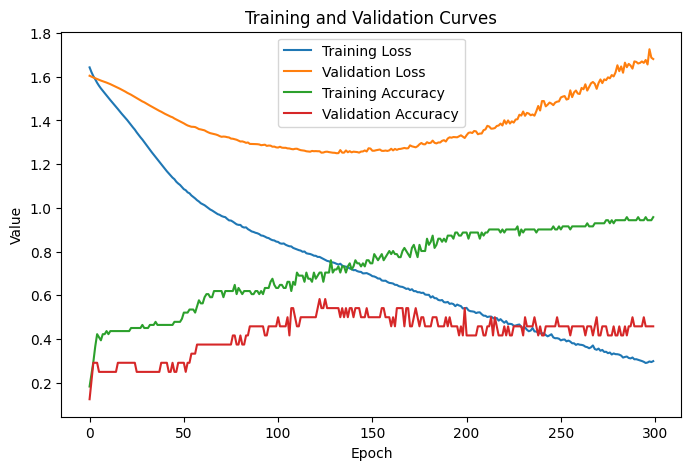

In [277]:
## Your code to plot training and validation curves in a single plot (Make changes in the model cell to be able to do this) : TODO

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Training and Validation Curves')
plt.legend()
plt.show()

In [278]:

pred_probs = keras_model.predict(X_test_nn)

prediction_column_index = np.argmax(pred_probs, axis=1)
prediction_labels = [y_train_cat.cat.categories[i] for i in prediction_column_index]
true_labels = [y_train_cat.cat.categories[i] for i in y_test_labels]

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(true_labels, prediction_labels))

print("\nClassification Report:")
print(classification_report(true_labels, prediction_labels))

print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, prediction_labels))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Accuracy: 0.5952380952380952

Classification Report:
              precision    recall  f1-score   support

     Average       0.50      0.62      0.56         8
        High       0.62      0.62      0.62         8
         Low       0.40      0.50      0.44         8
   Very High       1.00      0.78      0.88         9
    Very Low       0.57      0.44      0.50         9

    accuracy                           0.60        42
   macro avg       0.62      0.59      0.60        42
weighted avg       0.63      0.60      0.60        42


Confusion Matrix:
[[5 2 1 0 0]
 [3 5 0 0 0]
 [1 0 4 0 3]
 [1 1 0 7 0]
 [0 0 5 0 4]]


### Regularization: Dropout and Batch Normalization

Implement regularization techniques such as **Dropout** and **Batch Normalization** to improve generalization and observe the change in performance.

> **Note:** Compare training vs. test (or validation) loss and accuracy before and after adding regularization.

In [279]:
# Write your lines of code here: TODO
from tensorflow.keras.layers import Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam

keras_model_reg = Sequential([
    Input(shape=(feature_count,)),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')
])

keras_model_reg.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

history_reg = keras_model_reg.fit(
    X_train_nn,
    y_train_nn,
    batch_size=20,
    epochs=300,
    validation_split=0.25,
    verbose=1
)

Epoch 1/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 215ms/step - accuracy: 0.2139 - loss: 2.2828 - val_accuracy: 0.2500 - val_loss: 1.5995
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.2524 - loss: 1.9580 - val_accuracy: 0.1667 - val_loss: 1.5893
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.2939 - loss: 1.8700 - val_accuracy: 0.2500 - val_loss: 1.5808
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3189 - loss: 1.7785 - val_accuracy: 0.3333 - val_loss: 1.5737
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4157 - loss: 1.5330 - val_accuracy: 0.2083 - val_loss: 1.5668
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4084 - loss: 1.3626 - val_accuracy: 0.2500 - val_loss: 1.5577
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3721 - loss: 1.6468 - val_accuracy: 0.2917 - val_loss: 1.5489
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4300 - loss: 1.3488 - val_accuracy: 0.2917 - val_loss

### Activation Function Experimentation

Experiment with different activation functions — **ReLU**, **LeakyReLU**, **Tanh**, and **Sigmoid** — and compare their impact on model performance.


Training with relu activation

Training with tanh activation

Training with sigmoid activation

Training with leakyrelu activation

Test Accuracy Comparison:
relu: 0.5952
tanh: 0.4524
sigmoid: 0.5714
leakyrelu: 0.5238


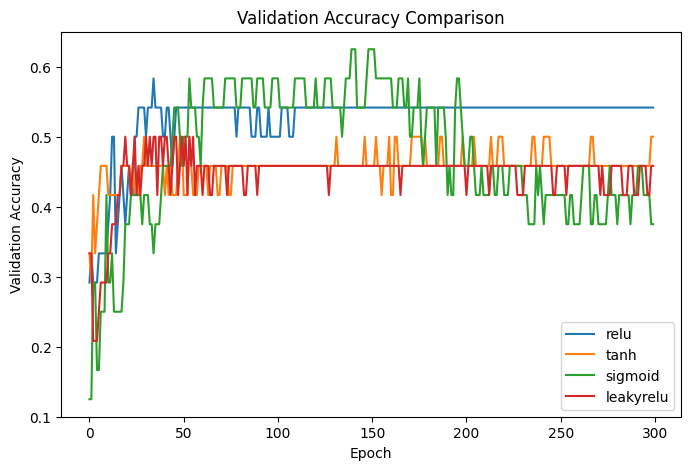

In [280]:
# Activation Function Experimentation
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Input, LeakyReLU
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Build model function
def build_model(activation_name):

    model = Sequential()
    model.add(Input(shape=(feature_count,)))

    if activation_name == "leakyrelu":
        model.add(Dense(128))
        model.add(LeakyReLU())
        model.add(Dense(64))
        model.add(LeakyReLU())
        model.add(Dense(32))
        model.add(LeakyReLU())
    else:
        model.add(Dense(128, activation=activation_name))
        model.add(Dense(64, activation=activation_name))
        model.add(Dense(32, activation=activation_name))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(),
        metrics=['accuracy']
    )

    return model


activations = ["relu", "tanh", "sigmoid", "leakyrelu"]

histories = {}
results = {}

for act in activations:
    print(f"\nTraining with {act} activation")

    model = build_model(act)

    history = model.fit(
        X_train_nn,
        y_train_nn,
        epochs=300,
        batch_size=20,
        validation_split=0.25,
        verbose=0
    )

    loss, acc = model.evaluate(X_test_nn, y_test_nn, verbose=0)

    histories[act] = history
    results[act] = acc

print("\nTest Accuracy Comparison:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")


# Plot validation accuracy comparison
plt.figure(figsize=(8,5))

for act in activations:
    plt.plot(histories[act].history['val_accuracy'], label=act)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

---

## 8. Explainability – SHAP Feature Importance

To better understand the model's predictions, we will use **SHAP (SHapley Additive exPlanations)** to analyze feature importance.

**How SHAP works:**

- SHAP assigns each feature a contribution score for every prediction.
- It uses Shapley values (from cooperative game theory) to fairly distribute importance across features.

We will apply SHAP to visualize and interpret the model's feature contributions.

/tmp/ipykernel_285/1537598301.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_processed_df)


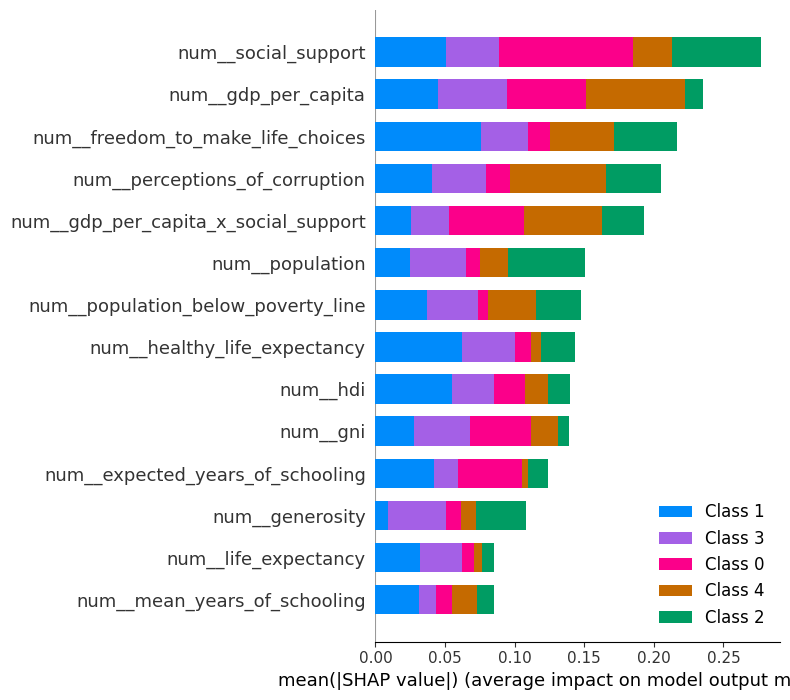

In [281]:
import shap
import pandas as pd

# Use the same processed features
X_test_processed = X_test_nn

# get name
feature_names = preprocess.get_feature_names_out()
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names)

# choose model
explainer = shap.Explainer(keras_model, X_test_processed_df)

#calcu&plot
shap_values = explainer(X_test_processed_df)

shap.summary_plot(shap_values, X_test_processed_df)

### Experimentation

In [282]:
## You are encouraged to try more experimentation and any other models by adding more code cells to this notebook:

## You can also try to import any new dataset pertaining to countries, merge it, and see if it helps the predictions.
## If it does not, try to explain why it wasn't helpful by exploring variable relationships.

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

model = KNeighborsClassifier(n_neighbors=5)
model.fit(preprocessor(X_train), y_train_labels)

pred = model.predict(preprocessor(X_test))

print(classification_report(y_test_labels, pred))

              precision    recall  f1-score   support

           0       0.62      0.56      0.59         9
           1       0.43      0.38      0.40         8
           2       0.50      0.75      0.60         8
           3       0.60      0.75      0.67         8
           4       1.00      0.56      0.71         9

    accuracy                           0.60        42
   macro avg       0.63      0.60      0.59        42
weighted avg       0.64      0.60      0.60        42



---

## 9. Final Report Submission (GitHub)

This is your final project to showcase on GitHub.

### Instructions

1. Create a new notebook for the final report.
2. Include relevant visualizations.
3. Reproduce the code for the best-performing model(s) and display results.
4. Summarize key insights and observed behaviors.
5. Present the work in a clean, concise report format (within the `.ipynb`).
6. Upload the final notebook to a new repository on your personal GitHub account.
7. Paste the link to your final repository at the top of this notebook where requested.